# Pricing d'une option européenne : BLACK-SCHOLES ET MONTE CARLO

**Auteur : HAYANA Sébastien**  
**Formation :Master 2 en Probabilités, Statistique et Finance**  
**Établissement : Université de Yaoundé 1**  
**Cameroun, 2026**



## Introduction

Une option est un produit dérivé dont la valeur dépend d'un actif sous-jacent. Dans ce projet, je m'intéresse à un call européen, qui donne le droit, mais pas l'obligation, d'acheter le sous-jacent au prix d'exercice $K$ à la date d'échéance $T$.

Le payoff du call à l'échéance est : $$ \max(S_T-K,0). $$

Le problème consiste à déterminer la valeur actuelle de ce gain futur et incertain.

Pour répondre à cette question, je compare une méthode analytique, Black-Scholes, à une méthode numérique, Monte Carlo.


## Objectifs

Les objectifs de ce projet sont les suivants :

* calculer le prix théorique d'un call européen avec Black-Scholes ;
* estimer le même prix par simulation Monte Carlo ;
* comparer les deux résultats ;
* étudier la convergence de Monte Carlo ;
* mesurer l'erreur standard de l'estimation ;
* analyser l'effet de la volatilité, de la maturité et du prix d'exercice ;
* discuter les hypothèses et les limites du modèle.

## Rappel sur l'option d'achat européenne

Une option d'achat, appelée call, donne à son acheteur le droit d'acheter un actif à un prix fixe à l'avance , appelée prix d'exercice ou prix strike. 

L'option européenne ne peut être exercée qu'à la date d'échéance.En outre, le gain de l'acheteur à cette date est  max( $S_T$ -$ K$ , 0) où $S_T$ est le prix de l'actif à l'échéance de date $T$ et $K$ est le prix strike.

Si $S_T$  est supérieur à $K$ alors le gain de l'option est positive , sinon le gain est carrément nul.

## Les paramètres utilisées

Le prix d'une option dépend notamment des paramètres suivants:

**$S_0$: le prix actuel de l'actif;**

**K: le prix d'exercice;**

**T: la durée jusqu'à l'échéance;**

**r: le taux sans risque de l'actif;**

**$ \sigma^{2} $: la volatilité de l'actif.**

Nous débutons dans ce projet avec des valeurs fixées afin de comprendre le fonctionnement des méthodes.

## VALEURS CHOISIES POUR UN EXEMPLE

Pour commencer , nous choisissons des valeurs simples et fixées pour construire un exemple simple, ce qui permettra de comprendre les méthodes avant d'utiliser d'éventuelles données financières réelles.

$S_0$ = 100 : L'actif vaut 100 aujourd'hui.

$K$ = 100 : L'acheteur du call pourra acheter à 100.

$T$ = 1 : il reste un an avant l'échéance.

$r$ = 5 % : Taux  sans risque pour ramener un prix futur à aujourd'hui.

$\sigma^{2}$ = 20 % : volatilité ou amplitude habituelle des prix.s réelles.

## Prix recherché

Dans cet exemple, $S_0 $ représente le prix actuel de l'actif sous jacent et $K$ représente le prix du call.
Le prix de l'actif à la date d'échéance T noté $S_T$ est inconnu.

L'objectif ici est donc d'estimer le prix du call noté ici $C$ à partir des paramètres choisis ci dessus.

Le prix $C$ correspond à la prime que l'acheteur devra payer pour obtenir le droit d'acheter l'actif à la date d'échéance $T$.


## Calcul du prix avec le modèle de BLACK SCHOLES

La formule de Black-Scholes permet d'obtenir une estimation théorique du prix actuel d'un call européen.

Elle est donnée par : 

 $$
 C = S_0N(d_1)-Ke^{-rT}N(d_2)
 $$

où les quantités d1 et d2 sont définies par :

$$
d_1 = \frac{\ln(\frac{S_0}{K}) + (r + \frac{\sigma^{2}}{2})T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Dans cette formle, $ N $ représente la fonction de repartition  de la loi normale standard.
 Il est très que cette formule utilise le prix actuel de l'actif sous jacent, le prix d'exercice , la date d'échéance ou la maturité, la volatilité , et le taux sans risque pour calculer le prix théorique du call aujourd'hui.



In [1]:
from scipy.stats import norm

In [2]:
import numpy as np
S0 = 100
K = 100
r = 0.05
T = 1
sigma = 0.20

d1 = (np.log(S0/K) + (r+ 0.5 * sigma**2)*T )/ (sigma* np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

print( "d1=", round(d1,2))
print("d2=", round(d2,2))

d1= 0.35
d2= 0.15


Après le calcul de $d_1$ et $d_2$ , nous calculons $N(d1)$ et $N(d2)$ puis le prix du call voulu:

In [3]:
N_d1 = norm.cdf(d1)
N_d2 = norm.cdf(d2)
print("N(d1)=",N_d1)
print("N(d2)=",N_d2)

N(d1)= 0.6368306511756191
N(d2)= 0.5596176923702425


In [4]:
call_price_bs =  S0* N_d1 - K* np.exp(-r*T)*N_d2

print( " Le prix théorique du call est donc:",call_price_bs)

 Le prix théorique du call est donc: 10.450583572185565


## Interprétation du résultat du modèle de Black Scholes

Avec nos paramètres choisis, le modèle de Black Scholes donne un prix théorique du call d'environ 10.45.
Ce prix ne correspond au prix actuel de l'actif sous-jacent comme on pourrait le penser mais à la prime estimée du call aujourd'hui tandis que le prix actuel de l'actif est de 100.


##  Estimation du prix du call avec Monte-Carlo

La méthode de Monte-Carlo consiste à simuler plusieurs valeurs possibles du prix de l'actif à l'échéance.

Pour chaque scénario, je calcule d'abord le gain du call : $$\max(S_T - K)$$

Ensuite, pour chaque gain , nous le ramenons à aujourd'hui avec le facteur d'actualisation:
$$ e^{-rT} $$.
Enfin , je prends la moyenne des gains actualisées.

Naturellement , la formule estimée du prix de Monte-Carlo est donc:

$$ e^{-rT}\frac{1}{N}\sum_{i=1}^N(\max(S_T^{(i)}-K) $$ où $N$ est le nombre de scénarios utilisés.



## Nombre de simulations 

Je commence avec 10000 simulations simulés.

Ce nombre permet d'obtenir effectivement une première estimation de prix.
Plus tard,je comparerai plusieurs nombres de simulations afin d'observer comment notre résultat ou estimation se stabilise.

In [5]:
np.random.seed(42) # Pour avoir des simulations reproductibles avec les mêmes sequences de valeurs lorsqu'on réexécute.

N = 10000 # Nos 10000 scénarios

Z = np.random.standard_normal(N) # Nos 10000 chocs aléatoires selon une loi normale standard

ST = S0 * np.exp( (r-0.5*sigma**2)*T + sigma* np.sqrt(T)*Z )

print("Nombre de scénarios:", len(ST))
print("Prix final moyen simulé:", ST.mean())
print("Prix final minimum:", ST.min())
print("Prix final maximum:", ST.max())



Nombre de scénarios: 10000
Prix final moyen simulé: 105.09703823314912
Prix final minimum: 47.02550601416886
Prix final maximum: 225.97349808269075


### Première observation des scénarios simulés 

Ce code précédent nous génère 10000 scénarios du prix de l'actif à  l'échéance de date $T$ à l'aide de la formule de prix solution du modèle de Black Scholes defini par :

$$ S_0e^{(r-\frac{\sigma^{2}}{2})T - \sigma\sqrt{T}Z} $$

La moyenne,le maximun, le minimun permettent de décrire l'ensemble des scénarios simulés. Il ne représente pas encore le prix du call.
Le prix du call sera calculé à l'étape suivante en utilisant le gain du call pour chaque scénario simulé.




### Calcul du gain du call dans chaque scénario

Pour chaque prix simulé à l'échéance , je calcule le gain du call appelé payoffs avec : $$ \max(S_T-K) $$

Si le prix final est supérieur au prix d'exercice,le gain du call n'est autre que la différence entre le prix final et le prix d'exercice.

Si le prix final est inférieur au prix d'exercice alors le gain du call vaut zéro, car l'acheteur n'exerce pas son droit.

In [6]:
import numpy as np

payoffs = np.maximum(ST - K, 0)

print("Dix premiers gains :", payoffs[:10])
print("Gain moyen :", payoffs.mean())
print("Gain minimum :", payoffs.min())
print("Gain maximum :", payoffs.max())

Dix premiers gains : [13.8080226   0.23498965 17.29684912 39.73896651  0.          0.
 41.31801116 20.1399282   0.         14.85634743]
Gain moyen : 10.985961590306978
Gain minimum : 0.0
Gain maximum : 125.97349808269075


## Actualisation des gains

Les gains calculés précédemment correspondent à des montants reçus à la date d'échéance.

Pour les exprimer en valeur actuelle, je les actualise avec le facteur d'actualisation $ e^{-rT} $.

Le prix du call sera ensuite obtenu en calculant la moyenne des gains actualisées.

In [7]:
discount_factor = np.exp(-r * T)

print("Facteur d'actualisation :", discount_factor)

Facteur d'actualisation : 0.951229424500714


In [8]:
discounted_payoffs = discount_factor * payoffs

print("vingts premiers gains actualisés :", discounted_payoffs[:20])

vingts premiers gains actualisés : [13.13459739  0.22352907 16.45327184 37.80087424  0.          0.
 39.30290798 19.15769231  0.         14.13179481  0.          0.
  7.75699375  0.          0.          0.          0.          9.25513346
  0.          0.        ]


In [9]:
call_price_mc = discounted_payoffs.mean()

print("Prix estimé du call par Monte Carlo :", call_price_mc)

Prix estimé du call par Monte Carlo : 10.450169921134657


### Résultat du prix de Monte-Carlo

Le prix Monte Carlo est obtenu en faisant la moyenne des gains actualisées sur l'ensemble des 10000 scénarios simulés.
Ce prix est une estimation numérique du prix actuel du call. Il peut être légèrement différent du prix obtenu avec Black-Scholes,car il dépend du nombre de simulations et des tirages aléatoires utilisés.

## Comparaison des deux méthodes 

Je compare maintenant le prix obtenu avec la formule de Black - Scholes et le prix obtenu par simulation de Monte Carlo.
Black - Scholes fournit une valeur calculée directement avec une formule tandis que Monte Carlo fourit une estimation à partir des scénarios simulés .Les deux valeurs devraient être proches, mais elles ne sont pas nécessairement exactement identiques .

In [10]:
print("Prix Black-Scholes :", call_price_bs)  # Affichage pour la comparaison des deux valeurs
print("Prix Monte Carlo :", call_price_mc)

Prix Black-Scholes : 10.450583572185565
Prix Monte Carlo : 10.450169921134657


In [11]:
difference = call_price_mc - call_price_bs
erreur_absolue = np.abs(difference)

print("Différence signée de prix entre Monte Carlo et Black-Scholes:",difference)
print("écart absolue:",erreur_absolue)

print(f"Prix Black- Scholes:{call_price_bs:.2f}")     
print(f"Prix Monte Carlo:{call_price_mc: .2f}")               
print(f"Écart absolue:{erreur_absolue: .4f}")

Différence signée de prix entre Monte Carlo et Black-Scholes: -0.0004136510509074043
écart absolue: 0.0004136510509074043
Prix Black- Scholes:10.45
Prix Monte Carlo: 10.45
Écart absolue: 0.0004


 ### Petite analyse et interprétation

Le prix de Black-Scholes est calculé directement avec une formule dans le cadre du modèle.

Le prix Monte Carlo est une estimation numérique obtenue à partir d'un nombre limité de scénarios aléatoires.

J'ai remarqué que les deux prix sont légèrement différent en présentant un léger écart entre les deux.En revanche, lorque'ils sont arrondis à deux chiffres après la virgule, les deux prix sont identiques.Cette égalité provient de l'arrondi. 

Pour comparer correctement , il est nécessaire d'observer plusieurs chiffres après la virgule ou plus simplement d'avoir une arrondi de l'écart absolue à quatres chiffres après la virgule. Dans ce cas , l'écart absolue est significatif. 

Le prix du modèle de Black-Scholes est probablement légèrement différent du prix de Monte-Carlo car il est obtenu à partir d'un nombre limité de scénarios aléatoires. En augmentant le nombre de simulations , le prix Monte Carlo devrait se rapprocher du prix Black-Scholes.

## Convergence de la méthode de Monte Carlo

### Objectif de cette partie

Après avoir calculé le prix du call avec la méthode de Black-Scholes, je souhaite vérifier si une méthode numérique fondée sur des simulations aléatoires permet d'obtenir une valeur proche.

Pour cela, je vais augmenter progressivement le nombre de simulations et observer l'évolution du prix estimée par Monte Carlo. Cette étude me permettra de comprendre la convergence de la méthode et de mesurer l'incertitude associée à chaque estimation.

### Rappel du prix théorique

Dans le cadre risque-neutre, le prix d'un call européen sans dividendes est égal à l'espérance actualisée de son payoff:  $$ \mathbb{E}^{\mathbb{Q}}\left[e^{-rT}(S_T-K)^+\right] $$  où $$ (x)^+ = \max(x,0) $$.

Le terme $$(S_T-K)^+$$ représente le gain du call à l'échéance. Si le prix final du sous-jacent est supérieur au prix d'exercice, le détenteur exerce son option. Dans le cas contraire, il n'exerce pas l'option et son gain est nul.

Pour simplifier l'écriture, je définis le payoff actualisé par : $$ X = e^{-rT}(S_T-K)^+ $$.

Le prix théorique du call devient alors :  $$ C_0 = \mathbb{E}^{\mathbb{Q}}[X] $$.

Cette expression constitue le point de départ de la méthode de Monte Carlo : je vais estimer l'espérance de $X$ en simulant un grand nombre de réalisations.

### Estimateur Monte Carlo

Pour chaque scénario $i$, je simule une valeur du prix du sous-jacent à l'échéance, notée $S_T^{(i)}$. Le payoff actualisé correspondant est :

$$
X_i= e^{-rT}\max\left(S_T^{(i)}-K,0\right),\qquad i=1,\ldots,N.
$$

Après avoir généré \(N\) scénarios, j'estime le prix du call par la moyenne des payoffs actualisés :
$$ \widehat{C}_N = \frac{1}{N}\sum_{i=1}^{N}X_i $$

Comme le facteur d'actualisation est identique pour tous les scénarios, cette formule peut également s'écrire :
$$
\widehat{C}_N=e^{-rT}\frac{1}{N}\sum_{i=1}^{N}\max\left(S_T^{(i)}-K,0\right).
$$

Le prix Monte Carlo est donc une moyenne empirique. Il ne correspond pas au résultat d'un scénario unique, mais à la moyenne de l'ensemble des résultats obtenus issus sur l'ensemble des scénarios simulés au nombre de N simulations.

### Loi des grands nombres

Les variables $X_1,\ldots,X_N$ sont supposées indépendantes et de même loi que $X$. D'après la loi forte des grands nombres :

$$
\frac{1}{N}\sum_{i=1}^{N}X_i\xrightarrow[N\to\infty]{\text{p.s.}}\mathbb{E}^{\mathbb{Q}}[X].
$$


Comme : $$ \mathbb{E}^{\mathbb{Q}}[X]=C_0, $$   on obtient : $$ \widehat{C}_N\xrightarrow[N\to\infty]{\text{p.s}} C_0. $$

Cette relation signifie que le prix Monte Carlo converge vers le prix théorique du call lorsque le nombre de simulations tend vers l'infini.

Dans mon projet, le prix de Black-Scholes sert de référence théorique. Je m'attends donc à ce que l'estimation Monte Carlo se rapproche globalement de ce prix lorsque $N$ augmente.

Il faut toutefois préciser que cette convergence n'est pas nécessairement monotone. Les scénarios étant générés aléatoirement, le prix obtenu avec un certain nombre de simulations peut parfois être plus proche du prix de Black-Scholes que celui obtenu avec un nombre légèrement supérieur. Ce qui est important est la tendance générale vers la valeur théorique et la diminution progressive de l'incertitude.

### Variance de l'estimateur

La précision du prix Monte Carlo dépend de la dispersion des payoffs simulés. Pour l'étudier, je considère la variance de l'estimateur :   

 $$ \operatorname{var}(\widehat{C}_N) = \operatorname{var}\left(\frac{1}{N}\sum_{i=1}^{N}X_i\right).$$

 Comme les simulations $X_i$ sont supposées indépendantes, les variances s'additionnent et les covariances sont nulles. On obtient donc :

 $$ \operatorname{Var}(\widehat{C}_N) =\frac{1}{N^2}\sum_{i=1}^{N}\operatorname{Var}(X_i).$$

 Les variables $X_i$ ayant la même variance que $X$, cette expression devient :

 $$ \operatorname{Var}(\widehat{C}_N)= \frac{1}{N^2}\cdot N\operatorname{Var}(X)=\frac{\operatorname{Var}(X)}{N} $$

Cette formule montre déjà que la variance de l'estimation diminue lorsque le nombre de simulations augmente.






### Erreur standard

En prenant la racine carrée de la variance précédente, j'obtiens l'écart-type de l'estimateur, appelé erreur standard :

$$ SE(\widehat{C}_N) = \sqrt{\operatorname{Var}(\widehat{C}_N)}.$$

Comme :
$$ \operatorname{Var}(\widehat{C}_N)=\frac{\operatorname{Var}(X)}{N},$$

alors :

$$SE(\widehat{C}_N)=\frac{\sigma_X}{\sqrt{N}},$$

où :

$$
\sigma_X=\sqrt{\operatorname{Var}(X)} 
$$
est l'écart-type théorique du payoff ou gain actualisé.

Cette formule est importante, car elle montre que l'erreur diminue en fonction de la racine carrée du nombre de simulations.

En pratique, je ne connais pas $\sigma_X$. Je l'estime donc à partir des payoffs actualisés simulés. L'écart-type empirique corrigé est :


$s_X$ = $$ \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}\left(X_i-\overline{X}\right)^2},$$
où :
$$ \overline{X} =\frac{1}{N}\sum_{i=1}^{N}X_i=\widehat{C}_N.$$

L'erreur standard estimée est alors :

$$ \widehat{SE}_N=\frac{s_X}{\sqrt{N}}.$$

Dans le code Python, cette formule sera traduite par :

<<sample_std = np.std( discounted_payoffs, ddof=1 )>>

<<standard_error = sample_std / np.sqrt( n_simulations )>>

La première ligne estime la dispersion des payoffs actualisés. La seconde divise cette dispersion par $\sqrt{N}$, conformément à la formule théorique de l'erreur standard.



### Rôle de ddof=1 

Les payoffs simulés ne représentent pas l'ensemble des scénarios possibles du marché. Ils constituent seulement un échantillon de ces scénarios.

C'est pourquoi j'utilise l'écart-type empirique corrigé, dont la formule contient $ N-1 $ au dénominateur :

$$ s_X=\sqrt{\frac{1}{N-1}\sum_{i=1}^{N}\left(X_i-\overline{X}\right)^2}.$$ 

Le paramètre **ddof=1** demande donc à NumPy d'utiliser $ N-1 $ au lieu de $ N $ dans le calcul de la variance empirique. Cette correction est utilisée lorsque l'on estime la dispersion d'une population à partir d'un échantillon.




## Vitesse de convergence

La relation : $$ \widehat{SE}_N = \frac{s_X}{\sqrt{N}} $$ montre que l'erreur diminue selon l'ordre :

$$\mathcal{O}\left(N^{-1/2}\right)$$

Cette convergence est relativement lente. Pour réduire l'erreur d'un facteur 2, il faut environ multiplier le nombre de simulations par 4 : $$\frac{1}{\sqrt{4N}}=\frac{1}{2\sqrt{N}}.$$

De même, pour réduire l'erreur d'un facteur 10, il faut environ multiplier le nombre de simulations par 100 :
  $$\frac{1}{\sqrt{100N}}=\frac{1}{10\sqrt{N}}.$$

 Cela explique pourquoi il est intéressant de comparer les valeurs :

$$
N\in\{100,\;1\,000,\;10\,000,\;100\,000\}.
$$

Cette comparaison permettra d'observer la stabilisation progressive de l'estimation.

  

### Théorème central limite

La loi des grands nombres explique pourquoi la moyenne Monte Carlo converge vers le prix théorique. Le théorème central limite permet quant à lui de décrire l'incertitude autour de cette moyenne.
Le théorème central limite complète la loi des grands nombres. Il affirme que, lorsque $N$ est suffisamment grand :


$$\frac{\widehat{C}_N-C_0}{\sigma_X/\sqrt{N}}\xrightarrow[N\to\infty]{\mathcal{L}}\mathcal{N}(0,1).$$

Cela signifie que l'erreur normalisée de l'estimation converge vers une loi normale centrée réduite.

En pratique, cela permet d'approximer la distribution de l'estimateur par :

$$\widehat{C}_N\approx\mathcal{N}\left(C_0,\frac{\sigma_X^2}{N}\right).$$

Cette approximation permet de construire un intervalle de confiance à 95 %. En pratique, j'utilise l'erreur standard estimée :

En remplaçant $\sigma_X$ par son estimation $s_X$, on peut construire un intervalle de confiance approximatif à 95 % :

$$\widehat{C}_N\pm1.96\,\widehat{SE}_N.$$

Cet intervalle s'écrit sous forme développée :

$$ \left[\widehat{C}_N-1.96\,\widehat{SE}_N,\;\widehat{C}_N+1.96\,\widehat{SE}_N\right]. $$

En pratique, cet intervalle me sert de garde-fou face au hasard. Comme mon ordinateur ne peut pas lancer une infinité de simulations, mes résultats conservent une part d'incertitude. Il permet de quantifier l'incertitude liée au nombre fini de simulations. Si le prix de Black-Scholes appartient à cet intervalle, c'est gagné! l'écart observé entre les deux méthodes reste compatible avec l'erreur statistique normale de la simulation.


### Protocole  du code 

Pour étudier la convergence, je vais effectuer les étapes suivantes :


1.choisir plusieurs nombres de simulations ;

2.générer les variables aléatoires nécessaires ;
 
3.simuler les prix du sous-jacent à l'échéance de date T ;
 
4.calculer le payoff de chaque call ;
 
5.actualiser chaque payoff avec notre facteur d'actualisation ;
 
6.calculer la moyenne des payoffs actualisés ;
 
7.calculer l'erreur standard ou l'erreur type ;
 
8.comparer chaque estimation au prix de Black-Schole


Les tailles de simulation utilisées seront :

$$ N\in\{100,\;1\,000,\;10\,000,\;100\,000\}.$$

Pour chaque valeur de $N$, je calculerai :  $$\widehat{C}_N $$  et $$\widehat{SE}_N.$$


Je pourrai ensuite vérifier trois propriétés :

* le rapprochement global du prix Monte Carlo avec le prix de Black-Scholes ;
* la diminution de l'erreur standard ;
* la stabilisation de l'estimation lorsque le nombre de simulations devient important.


### Interprétation attendue

Je m'attends à ce que l'estimation obtenue avec 100 simulations soit relativement instable, car elle repose sur un nombre limité de scénarios.

Avec 1 000 puis 10 000 simulations, les effets devraient s'améliorer. Le prix estimé devrait donc devenir plus stable.

Avec 100 000 simulations, l'erreur standard devrait être plus faible et l'estimation devrait généralement être proche du prix de Black-Scholes. Le résultat ne sera toutefois pas exactement égal à la valeur analytique, car Monte Carlo reste une méthode d'approximation fondée sur des variables aléatoires.

Cette étude me permet donc de vérifier numériquement la théorie : la moyenne des payoffs actualisés converge vers l'espérance théorique, et la précision de cette moyenne augmente avec le nombre de simulations.


## Mise en œuvre numérique

Je vais maintenant traduire le protocole précédent en Python.

In [12]:
simulation_sizes = [100, 1000, 10000, 100000]

mc_prices = []
mc_errors = []

for n_simulations in simulation_sizes:
    np.random.seed(42)

    Z = np.random.standard_normal(n_simulations)

    ST = S0 * np.exp( (r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z )

    payoffs = np.maximum(ST - K, 0)

    discounted_payoffs = np.exp(-r * T) * payoffs

    price_mc = np.mean(discounted_payoffs)

    sample_std = np.std(discounted_payoffs, ddof=1)

    standard_error = sample_std / np.sqrt(n_simulations)

    mc_prices.append(price_mc)
    mc_errors.append(standard_error)

In [13]:
for n_simulations, price_mc, error_mc in zip(simulation_sizes, mc_prices, mc_errors):
    print(
        f"N = {n_simulations:>6} | "                    # Pour rendre l'affichage plus propre , il est préférable de l'afficher ainsi ...
        f"Prix Monte Carlo = {price_mc:.6f} | "
        f"Erreur standard = {error_mc:.6f}"
        )

print(f"\nPrix Black-Scholes = {call_price_bs:.6f}")   # ça me sert de référence pour la comparaison 

N =    100 | Prix Monte Carlo = 8.159991 | Erreur standard = 1.178293
N =   1000 | Prix Monte Carlo = 10.516569 | Erreur standard = 0.472961
N =  10000 | Prix Monte Carlo = 10.450170 | Erreur standard = 0.147813
N = 100000 | Prix Monte Carlo = 10.473892 | Erreur standard = 0.046589

Prix Black-Scholes = 10.450584


## Interprétation des résultats de convergence

Pour chaque valeur de $N$, j'ai calculé une nouvelle estimation du prix du call à partir des payoffs actualisés.

Lorsque $N$ est faible, l'estimation Monte Carlo est plus sensible aux tirages aléatoires. Le prix obtenu peut donc être relativement éloigné du prix de Black-Scholes.

Lorsque $N$ augmente, la moyenne des payoffs actualisés(prix Monte Carlo) devient généralement plus stable. Cela correspond à la loi des grands nombres : $$ \widehat{C}_N\longrightarrow C_0. $$

Je m'attends également à observer une diminution de l'erreur standard, conformément à la relation :
$$ \widehat{SE}_N = \frac{s_X}{\sqrt{N}}. $$

Les résultats ne doivent pas nécessairement se rapprocher du prix de Black-Scholes de façon parfaitement monotone lorsque N croît, car chaque estimation dépend de variables aléatoires. En revanche, la dispersion des estimations devrait diminuer globalement lorsque le nombre de simulations augmente de par sa formle.

Cette expérience permet donc de vérifier numériquement que l'augmentation du nombre de scénarios améliore la précision du prix Monte Carlo.



## Visualisation de la convergence

Après avoir calculé les prix Monte Carlo pour plusieurs nombres de simulations, je vais représenter graphiquement les résultats.

L'axe horizontal représente le nombre de simulations $N$, tandis que l'axe vertical représente le prix estimé du call par la méthode Monte Carlo :  $$ \widehat{C}_N $$

Les points du graphique correspondent aux estimations Monte Carlo obtenues pour :
$$ N\in\{100,\;1\,000,\;10\,000,\;100\,000\}. $$

J'ajoute également une ligne horizontale représentant le prix de Black-Scholes :$$ C_{BS}. $$

Cette ligne sert de référence théorique. Si la méthode de Monte Carlo fonctionne correctement,alors les estimations devraient se rapprocher globalement de cette ligne lorsque le nombre de simulations augmente.

Les estimations ne sont pas nécessairement monotones, car elles dépendent de tirages aléatoires. Toutefois, leur dispersion devrait diminuer lorsque $N$ augmente.

J'utilise une échelle logarithmique sur l'axe horizontal, car le nombre de simulations varie fortement. Les valeurs 100, 1000, 10000 et 100000 sont séparées par des facteurs 10. L'échelle logarithmique permet donc de représenter ces valeurs de manière plus lisible au détriment d'utiliser une échelle normale .



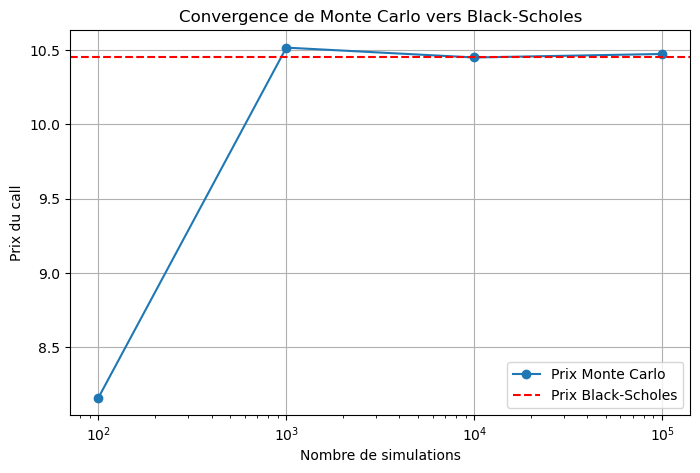

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot( simulation_sizes,mc_prices,marker="o",label="Prix Monte Carlo" )

plt.axhline( y=call_price_bs,color="red",linestyle="--",label="Prix Black-Scholes")

plt.xscale("log")    # Mon échelle logarithmique 

plt.xlabel("Nombre de simulations")
plt.ylabel("Prix du call")
plt.title("Convergence de Monte Carlo vers Black-Scholes")

plt.legend()
plt.grid(True)

plt.show()

## Interprétation du graphique

Les points représentent les prix estimés par Monte Carlo pour différents nombres de simulations. La ligne rouge en pointillés représente le prix théorique obtenu avec Black-Scholes.

Lorsque le nombre de simulations est faible, le prix Monte Carlo peut être relativement éloigné du prix de référence. Cette différence s'explique par le nombre limité de scénarios et par le caractère aléatoire de la simulation.

Lorsque le nombre de simulations augmente, les estimations deviennent généralement plus stables et se rapprochent du prix de Black-Scholes. Cette observation est cohérente avec la loi des grands nombres :

$$ \widehat{C}_N\longrightarrow C_{BS}\qquad\text{lorsque}\qquad N\to\infty. $$

Le graphique confirme donc l'idée théorique selon laquelle l'augmentation du nombre de simulations améliore la précision de l'estimation Monte Carlo.



## Sensibilité du prix à la volatilité

Dans cette partie, je vais étudier l'influence de la volatilité $\sigma$ sur le prix du call européen que nous avons étudié.

La volatilité mesure l'amplitude des variations possibles du prix du sous-jacent. Dans le modèle de Black-Scholes, je remarque qu'elle intervient directement dans les quantités $d_1$ et $d_2$, puis dans le prix du call : $$ C_{BS}=S_0N(d_1)-Ke^{-rT}N(d_2), $$  avec  $$ d_1=\frac{\ln(S_0/K)+\left(r+\frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}} $$  et $$ d_2=d_1-\sigma\sqrt{T}. $$  

Je vais conserver constants les autres paramètres du modèle :  $$S_0,\quad K,\quad T,\quad r,$$ et  faire varier uniquement $\sigma$.

Pour un call européen, le prix augmente généralement lorsque la volatilité augmente. L'explication financière est la suivante : une volatilité plus élevée élargit l'éventail des prix possibles à l'échéance. Le détenteur du call ne peut pas perdre plus que la prime payée et naturellement tout le monde le souhaite , car il peut choisir de ne pas exercer l'option si $S_T<K$. En revanche, si le prix du sous-jacent augmente fortement, le gain du call peut devenir important.

Ainsi, une hausse de la volatilité augmente le potentiel de gain sans augmenter symétriquement la perte du détenteur. Cette sensibilité positive du prix d'une option à la volatilité est appelée ***la vega***.

Mathématiquement, la vega du call est la dérivée du prix par rapport à la volatilité :
$$ \text{Vega}=\frac{\partial C_{BS}}{\partial \sigma}. $$

Dans le modèle de Black-Scholes sans dividendes :

$$\text{Vega}=S_0\sqrt{T}\varphi(d_1),$$  où $\varphi$ désigne la densité de la loi normale standard.

Comme cette quantité est positive, une augmentation de $\sigma$ entraînera généralement une augmentation du prix du call. 

Dans l'étude numérique, je vais utiliser plusieurs niveaux de volatilité :

$$
\sigma\in\{10\%,\;20\%,\;30\%,\;40\%\}.
$$

Pour chaque valeur, je calculerai le prix Black-Scholes et je comparerai les résultats. L'objectif est de vérifier numériquement la relation théorique entre volatilité et prix du call.



In [15]:
volatility_values = [0.10, 0.20, 0.30, 0.40]

volatility_prices = []

for sigma_value in volatility_values:
    d1 = ( np.log(S0 / K) + (r + 0.5 * sigma_value**2) * T ) / (sigma_value * np.sqrt(T))
    d2 = d1 - sigma_value * np.sqrt(T)

    call_price = ( S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2) )

    volatility_prices.append(call_price)


for sigma_value, price in zip( volatility_values,volatility_prices ):
    
    print(f"Volatilité : {sigma_value:.0%} | "f"Prix du call : {price:.6f}")

Volatilité : 10% | Prix du call : 6.804958
Volatilité : 20% | Prix du call : 10.450584
Volatilité : 30% | Prix du call : 14.231255
Volatilité : 40% | Prix du call : 18.022951


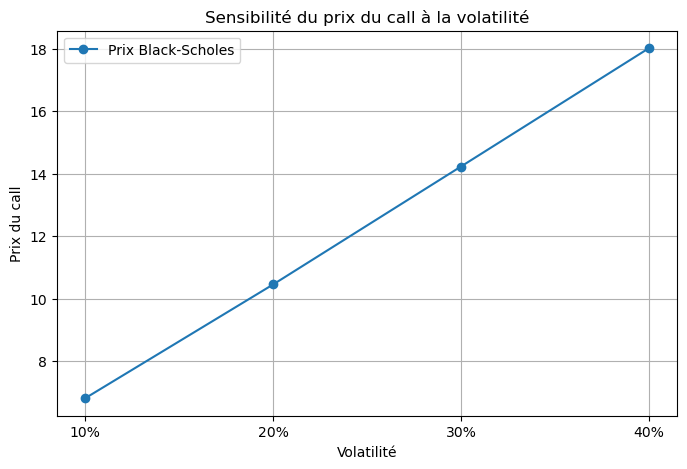

In [16]:
plt.figure(figsize=(8, 5))

plt.plot( volatility_values, volatility_prices, marker="o", label="Prix Black-Scholes" )
plt.xlabel("Volatilité")
plt.ylabel("Prix du call")
plt.title("Sensibilité du prix du call à la volatilité")

plt.xticks( volatility_values, [f"{value:.0%}" for value in volatility_values] ) # Il s'agit ici juste d'une compréhension de liste afin d'avoir les décimales en pourcentage sur l'axe horizontal qui est une norme dans la finance                        

plt.grid(True)
plt.legend()

plt.show()

## Interprétation de l'effet de la volatilité

Les résultats montrent que le prix du call augmente lorsque la volatilité augmente.

Cette relation est cohérente avec la théorie financière. La volatilité plus élevée signifie que le prix final du sous-jacent à l'échéance peut connaître des variations plus importantes. Pour le détenteur d'un call, les scénarios de forte hausse peuvent générer des gains importants, tandis que les scénarios de baisse sont limités par le fait que l'option peut ne pas être exercée bien évidemment pour ne pas perdre .

Le prix du call est donc une fonction croissante de la volatilité dans le cadre du modèle de Black-Scholes. Cette sensibilité est mesurée par la vega :

$$ \text{Vega} = \frac{\partial C_{BS}}{\partial \sigma}. $$


Dans notre étude, les prix calculés pour $10\%$, $20\%$, $30\% $ et $40\%$ permettent de vérifier numériquement que :

$$
\sigma_1<\sigma_2 \quad\Longrightarrow\quad C_{BS}(\sigma_1)<C_{BS}(\sigma_2).
$$

La volatilité constitue donc un paramètre essentiel du prix d'une option. Une mauvaise estimation de $\sigma $ peut entraîner une différence importante entre le prix théorique calculé et le prix observé sur le marché.
Nous devons donc faire attention à son estimation pour une contribution favorable à l'avenir.



## Sensibilité du prix à la maturité

Dans cette partie, je vais étudier l'influence de la durée jusqu'à l'échéance de notre T , notée $T$, sur le prix du call européen.

Dans le modèle de Black-Scholes, le prix du call est :

$$ C_{BS} = S_0N(d_1) - Ke^{-rT}N(d_2), $$

avec : $$d_1 = \frac{ \ln(S_0/K) + \left(r+\frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}} $$
et : $$ d_2=d_1-\sigma\sqrt{T}. $$

Je vais conserver constants les paramètres suivants :
$$
S_0,\quad K,\quad r,\quad \sigma,
$$
et faire varier uniquement la maturité $T$.

La maturité représente le temps restant avant l'expiration de l'option. Plus la maturité est longue, plus le sous-jacent dispose de temps pour évoluer et éventuellement dépasser le prix d'exercice $K$.

Pour un call européen, une maturité plus longue augmente généralement la valeur de l'option. Le détenteur bénéficie de davantage de temps pour profiter d'une hausse du sous-jacent, tandis que sa perte reste limitée à la prime payée si l'option expire sans valeur c'est à dire sans un gain.

La valeur du call ne dépend pas seulement de son gain immédiat, mais également de la possibilité que son prix devienne favorable avant l'échéance.

La sensibilité du prix d'une option au passage du temps  est appelée ***le theta***. Pour une position longue sur un call, ***le theta*** est généralement négatif lorsque le temps passe et que la maturité restante diminue.
Une option ne vaut pas seulement ce qu'elle rapporte aujourd'hui, elle vaut surtout pour l'espoir que l'action monte avant la date finale. C'est le $\theta $ qui mesure cette sensibilité au temps qui passe

Dans cette étude, je vais utiliser plusieurs maturités exprimées en années :
$$
T\in\{0.25,\;0.5,\;1,\;2\}.
$$
Ces valeurs correspondent respectivement à : 3 mois, 6 mois, 1 an , 2 ans.

Pour chaque valeur de $T$, je calculerai le prix du call avec Black-Scholes. L'objectif est de vérifier numériquement si une maturité plus longue produit un prix plus élevé dans notre exemple.

In [17]:
maturity_values = [0.25, 0.5, 1.0, 2.0]

maturity_prices = []

for T_value in maturity_values:
    d1 = ( np.log(S0 / K)  + (r + 0.5 * sigma**2) * T_value ) / (sigma * np.sqrt(T_value))
    d2 = d1 - sigma * np.sqrt(T_value)

    call_price = ( S0 * norm.cdf(d1) - K * np.exp(-r * T_value) * norm.cdf(d2) )

    maturity_prices.append(call_price)



for T_value, price in zip( maturity_values, maturity_prices ):
    print( f"Maturité : {T_value:.2f} an(s) | " f"Prix du call : {price:.6f}" )


Maturité : 0.25 an(s) | Prix du call : 4.614997
Maturité : 0.50 an(s) | Prix du call : 6.888729
Maturité : 1.00 an(s) | Prix du call : 10.450584
Maturité : 2.00 an(s) | Prix du call : 16.126780


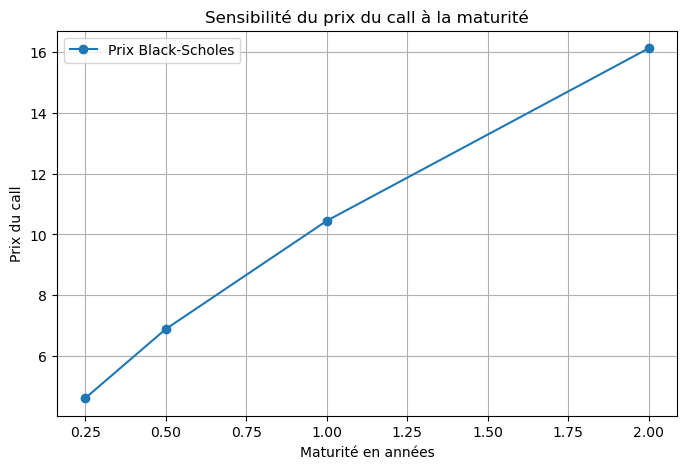

In [18]:
plt.figure(figsize=(8, 5))

plt.plot( maturity_values, maturity_prices, marker="o", label="Prix Black-Scholes" )
plt.xlabel("Maturité en années")
plt.ylabel("Prix du call")
plt.title("Sensibilité du prix du call à la maturité")

plt.grid(True)
plt.legend()
plt.show()

## Interprétation de l'effet de la maturité

Les résultats montrent comment le prix du call évolue lorsque la durée jusqu'à l'échéance augmente.

Dans notre exemple, le prix du call augmente généralement avec la maturité. Cette évolution est cohérente avec l'intuition financière : une échéance plus éloignée laisse davantage de temps au sous-jacent pour dépasser le prix d'exercice $K$

La maturité apporte donc une valeur temps supplémentaire à l'option. Cette valeur correspond à la possibilité que l'évolution future du sous-jacent rende l'option plus profitable avant son expiration.

Les résultats peuvent être résumés par la relation attendue :

$$ T_1<T_2 \quad\Longrightarrow\quad C_{BS}(T_1)\leq C_{BS}(T_2), $$ dans le cadre de notre exemple et sous les hypothèses du modèle.

En revanche, lorsque le temps passe, la maturité restante diminue. Cette perte progressive au fur et à mesure que le temps avance  est appelée le passage du temps ou le time decay. Elle est généralement mesurée par le theta.

Cette étude montre donc que le temps restant avant l'échéance est un facteur important comme les autres facteurs dans la valorisation d'un call européen.


Après avoir étudié l'influence de la volatilité et de la maturité, je vais maintenant analyser l'effet du prix d'exercice $K$ sur la valeur du call.
La prochaine étape sera donc l’étude de la sensibilité au prix d’exercice.

## Sensibilité du prix au prix d'exercice

Dans cette partie, je vais étudier l'influence du prix d'exercice $K$ sur le prix du call européen.

Le prix d'exercice est le prix auquel le détenteur du call peut acheter le sous-jacent à l'échéance. Le payoff du call est :  $$ \max(S_T-K,0). $$

Cette formule montre d'ailleurs directement le rôle de $K$. Pour un même prix final fixé $S_T$, une augmentation de $K$ réduit le montant $S_T-K$. Le call devient donc moins intéressant pour son détenteur.

Dans la formule de Black-Scholes : $$ C_{BS} = S_0N(d_1) - Ke^{-rT}N(d_2), $$

le prix d'exercice intervient directement dans le deuxième terme et indirectement dans $d_1 $et $d_2$ :

$$ d_1 = \frac{ \ln(S_0/K) + \left(r+\frac{1}{2}\sigma^2\right)T }{ \sigma\sqrt{T} } $$  et 
et :  $$ d_2=d_1-\sigma\sqrt{T}. $$

j'ai analysé l'impact du prix d'exercice sur la valeur du contrat. En tant qu'acheteur du Call, mon objectif est d'acquérir l'action sous-jacente au prix le plus bas possible. Ainsi, un prix d'exercice faible rend mon option beaucoup plus attractive et augmente sa valeur sur le marché. À l'inverse, un prix d'exercice trop élevé diminue la probabilité de gains et fait chuter le prix.

Pour un call, un prix d'exercice *faible* est généralement plus favorable, car il permet d'acheter le sous-jacent à un prix plus bas. À l'inverse, un prix d'exercice *élevé* rend l'exercice moins probable et réduit généralement la valeur du call.

La relation théorique attendue est donc : $$ K_1<K_2 \quad\Longrightarrow\quad C_{BS}(K_1)>C_{BS}(K_2). $$

Cette propriété peut également être observée à partir du payoff. Pour deux prix d'exercice $K_1<K_2$, on a : $$ \max(S_T-K_1,0)> \max(S_T-K_2,0). $$

j'ai étudié la notion de **moneyness**, qui désigne la position relative du prix actuel de l'action $S_{0}$ par rapport au prix d'exercice. J'ai ainsi classé les options en trois catégories : elles sont dites dans la monnaie $S_0 > K$ lorsqu'elles génèrent un gain immédiat, hors de la monnaie $S_0 < K$ si l'exercice est défavorable à l'instant là, et à la monnaie $S_0 \approx K$ lorsque les deux prix sont alignés ou presque similaires. Grâce à ce classement, j'ai pu comprendre pourquoi un contrat qui fait gagner de l'argent tout de suite vaut beaucoup plus cher qu'un simple contrat basé sur l'espoir

Dans cette étude, je vais utiliser plusieurs prix d'exercice :
$$ K\in\{80,\;90,\;100,\;110,\;120\}. $$

Pour chacun de ces prix, je calculerai le prix du call avec Black-Scholes et j'analyserai son évolution.

In [19]:
strike_values = [80, 90, 100, 110, 120]
strike_prices = []

for value in strike_values:
    d1 = (  np.log(S0 / value)  + (r + 0.5 * sigma**2) * T  ) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = ( S0 * norm.cdf(d1) - value * np.exp(-r * T) * norm.cdf(d2) )

    strike_prices.append(call_price)


for value, price in zip( strike_values, strike_prices ):
    print( f"Prix d'exercice : {value:>6.2f} | "  f"Prix du call : {price:.6f}" )
    

Prix d'exercice :  80.00 | Prix du call : 24.588835
Prix d'exercice :  90.00 | Prix du call : 16.699448
Prix d'exercice : 100.00 | Prix du call : 10.450584
Prix d'exercice : 110.00 | Prix du call : 6.040088
Prix d'exercice : 120.00 | Prix du call : 3.247477


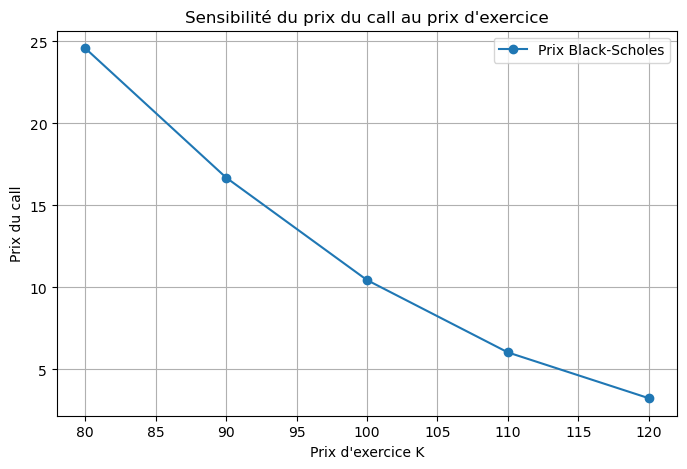

In [20]:
plt.figure(figsize=(8, 5))

plt.plot( strike_values, strike_prices, marker="o", label="Prix Black-Scholes" )
plt.xlabel("Prix d'exercice K")
plt.ylabel("Prix du call")
plt.title("Sensibilité du prix du call au prix d'exercice")

plt.grid(True)
plt.legend()

plt.show()

## Interprétation de l'effet du prix d'exercice

Les résultats montrent que le prix du call diminue généralement lorsque le prix d'exercice $K$ augmente.
Cette évolution est cohérente avec le payoff : $$ \max(S_T-K,0). $$

Pour un même prix final $S_T$, une augmentation de $K$ diminue le gain potentiel du call. Par exemple, si $S_T=120$, un prix d'exercice $K=80$ donne un payoff de : $$ \max(120-80,0)=40, $$ tandis qu'un prix d'exercice $K=110$ donne seulement : $$ \max(120-110,0)=10. $$

Les résultats vérifient globalement la propriété : $$ K_1<K_2 \quad\Longrightarrow\quad C_{BS}(K_1)>C_{BS}(K_2). $$

Cette analyse confirme que le prix d'exercice est un paramètre essentiel dans la valorisation d'un call européen.



Après avoir étudié l'influence de la volatilité, de la maturité et du prix d'exercice, je vais maintenant rassembler naturellement les principaux résultats et analyser les limites du modèle de Black-Scholes et de la simulation Monte Carlo.  

## Analyse globale des résultats

Dans ce projet, j'ai estimé le prix d'un call européen selon deux méthodes :

- la formule analytique de Black-Scholes ;
- la simulation numérique de Monte Carlo.

La formule de Black-Scholes fournit directement un prix théorique dans le cadre des hypothèses du modèle :
$$ C_{BS} = S_0N(d_1)- Ke^{-rT}N(d_2). $$

La méthode de Monte Carlo estime le même prix à partir de la moyenne des payoffs ou gains actualisés :
$$ \widehat{C}_{MC} = \frac{1}{N} \sum_{i=1}^{N} e^{-rT} \max\left(S_T^{(i)}-K,0\right). $$

Lorsque le nombre de simulations augmente, le prix Monte Carlo devient généralement plus stable et se rapproche du prix de Black-Scholes.

Cette convergence est cohérente avec la loi des grands nombres :
$$ \widehat{C}_{MC} \longrightarrow C_{BS} \qquad\text{lorsque}\qquad N\to\infty. $$

L'écart entre les deux prix ne signifie donc pas nécessairement qu'une méthode est incorrecte. Il provient principalement du caractère aléatoire et du nombre fini de simulations utilisé dans Monte Carlo.

## Analyse des paramètres

L'étude de sensibilité m'a permis d'observer l'influence de plusieurs paramètres sur le prix du call.

### Volatilité

Le prix du call augmente généralement lorsque la volatilité $\sigma$ augmente :
$$ \sigma_1<\sigma_2 \quad\Longrightarrow\quad C(\sigma_1)<C(\sigma_2). $$

Une volatilité plus importante agrandit l'éventail des prix possibles à l'échéance. Le détenteur du call bénéficie des scénarios de forte hausse, tandis que son risque de perte reste limité à la prime payée dans ce sens où il n'exerce pas le droit.

### Maturité

Dans notre exemple, le prix du call augmente généralement avec la maturité :
$$ T_1<T_2 \quad\Longrightarrow\quad C(T_1)\leq C(T_2). $$

Une durée plus longue laisse davantage de temps au sous-jacent pour dépasser eventuellement le prix d'exercice. Le temps restant constitue donc une source de valeur pour l'option.

### Prix d'exercice

Le prix du call diminue généralement lorsque le prix d'exercice augmente :

$$ K_1<K_2 \quad\Longrightarrow\quad C(K_1)\geq C(K_2). $$

Un prix d'exercice faible permet donc d'acheter le sous-jacent à un prix plus avantageux.

## Limites du modèle de Black-Scholes

Même si le modèle de Black-Scholes est utile pour obtenir un prix de référence, il repose sur plusieurs hypothèses qui simplifie le modèle.

Il s'agit de :

### Volatilité constante

Le modèle suppose que la volatilité $\sigma$ reste constante pendant toute la durée de l'option :

$$ \sigma_t=\sigma \qquad\text{pour tout }t\in[0,T]. $$

En pratique, **la volatilité varie au cours du temps comme on l'a vu dans mon premier projet sur l'analyse de la volatilité d'un indice de marché** et peut dépendre du niveau du marché, de l'échéance ou des conditions économiques.

### Taux sans risque constant

Le modèle suppose également que le taux sans risque $r$ est constant :

$$ r_t=r \qquad\text{pour tout }t\in[0,T]. $$ 

Dans la réalité, les taux d'intérêt évoluent dans le temps, ce qui devient pour moi une option à explorer dans le cadre de mes projets.

### Distribution des prix

Pour modéliser l'évolution de l'actif sous-jacent, nous utilisons le mouvement brownien géométrique, ce qui implique que les rendements suivent une loi normale et que les prix finaux sont log-normaux. Dans la réalité, cette hypothèse sous-estime la fréquence des événements extrêmes. Elle s'avère donc insuffisante pour capter les sauts de prix brutaux ou les pics de volatilité qui surviennent lors des crises financières par exemple.

### Absence de dividendes

La formule utilisée dans ce projet correspond à un actif sans dividendes c'est-à-dire où des parts de bénéfices ne sont pas versées. Si le sous-jacent verse des dividendes, il faut modifier la formule de Black-Scholes, car d'autres paramètres seront à tenir en compte.

### Marché sans friction

Le modèle suppose l'absence de coûts de transaction, de taxes, de problèmes de liquidité et de contraintes de financement. 

Dans la réalité, ces éléments peuvent modifier le prix auquel une option peut être achetée ou vendue.

### Type d'option

La formule standard de Black-Scholes s'applique directement aux options européennes. Elle ne tient pas compte d'un exercice anticipé, contrairement aux options américaines.

Ces hypothèses expliquent pourquoi le prix obtenu doit être interprété comme un prix théorique du modèle et non comme une valeur exacte du marché.









## Limites de la simulation Monte Carlo

La simulation Monte Carlo présente également certaines limites

### Convergence lente

L'erreur standard diminue selon : $$ \widehat{SE}_N = \frac{s_X}{\sqrt{N}}. $$
La convergence est donc relativement lente. Pour améliorer fortement la précision, il faut augmenter considérablement le nombre de simulations.

### Coût de calcul

Un nombre élevé de simulations améliore peut-être la précision mais augmente le temps de calcul et la consommation de ressources.

### Résultats aléatoires

Le prix de la méthode Monte Carlo dépend des tirages aléatoires utilisés.En effet, deux exécutions peuvent produire des valeurs légèrement différentes si la graine aléatoire n'est pas fixée.
La graine utilisée dans mon projet permet de rendre les résultats reproductibles : **np.random.seed(42)**

### Dépendance au modèle

Monte Carlo ne corrige pas les hypothèses de Black-Scholes. Il simule les prix à partir de la dynamique choisie : $$ S_T = S_0 \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}Z \right]. $$

Si la dynamique ne représente pas correctement le marché, une simulation plus importante ne rendra pas automatiquement le modèle plus réaliste pour le marché.

Monte Carlo réduit l'erreur numérique, mais il ne supprime pas l'erreur liée au modèle.

## Conclusion

L'objectif de ce projet était de valoriser un call européen et de comparer une méthode analytique à une méthode numérique.

J'ai d'abord calculé le prix du call avec la formule de Black-Scholes :
$$ C_{BS} = S_0N(d_1) - Ke^{-rT}N(d_2). $$

J'ai ensuite utilisé une simulation Monte Carlo. Pour chaque scénario, j'ai simulé le prix du sous-jacent à l'échéance, calculé le payoff du call et actualisé ce payoff. Le prix de l'option a été ensuite estimé par la moyenne des payoffs actualisés :
$$ \widehat{C}_{MC} = \frac{1}{N} \sum_{i=1}^{N} e^{-rT} \max\left(S_T^{(i)}-K,0\right). $$

La comparaison des deux méthodes montre que le prix Monte Carlo se rapproche généralement du prix de Black-Scholes lorsque le nombre de simulations augmente. Cette convergence est expliquée par la loi des grands nombres, tandis que l'erreur standard permet de mesurer la précision de l'estimation : 
$$ \widehat{SE}_N = \frac{s_X}{\sqrt{N}}. $$

L'analyse de sensibilité m'a également permis d'observer que le prix du call augmente généralement avec la volatilité et la maturité, mais diminue lorsque le prix d'exercice augmente.

Enfin, ce projet m'a permis de comprendre que Black-Scholes fournit un prix théorique fondé sur des hypothèses simplificatrices, tandis que Monte Carlo constitue une méthode numérique permettant d'approximer l'espérance du payoff actualisé.

Les deux méthodes sont donc complémentaires : Black-Scholes est rapide et analytique, alors que Monte Carlo est plus flexible mais plus coûteuse en calcul et soumise à une erreur statistique.

## Sources utilisées

La base théorique de ce projet provient principalement du support de cours de l'unité d'enseignement consacré à la modélisation financière stochastique et au pricing des contrats financiers, préparé par le Professeur Mbele Bidima Martin Le Doux et sont complètés par d'autres sources.

Les parties du cours les plus directement mobilisées sont :

* la valeur de l'argent dans le temps et l'actualisation ;
* le modèle classique de Black-Scholes ;
* l'évaluation des options européennes ;
* les méthodes de génération de nombres aléatoires ;
* les méthodes de Monte Carlo en financee.

Pour l'implémentation informatique, je me suis appuyé sur mes bases en Python ainsi que sur les documentations officielles de NumPy, SciPy et Matplotlib. Le code a été adapté, commenté et vérifié dans le cadre de ce projet.

Le projet reprend ces notions dans une application consacrée à la valorisation d'un call européen.

## Références

1. Mbele Bidima Martin Le Doux. (2025).
   Modélisation financière stochastique et pricing des contrats financiers.
   Support de cours de l'unité d'enseignement, Yaoundé, Cameroun, 20 mars 2025.

2. Boyle, P. P. (1977).
   Options: A Monte Carlo Approach.
   Journal of Financial Economics, 4(3), 323–338.
   https://doi.org/10.1016/0304-405X(77)90005-8

3. Black, F., & Scholes, M. (1973).
   The Pricing of Options and Corporate Liabilities.
   Journal of Political Economy, 81(3), 637–654.
   https://doi.org/10.1086/260062

4. NumPy Developers.
   NumPy Documentation.
   https://numpy.org/doc/

5. SciPy Developers.
   SciPy Documentation.
   https://docs.scipy.org/doc/scipy/

6. Matplotlib Developers.
   Matplotlib Documentation.
   https://matplotlib.org/stable/